**DB CHALLENGE** 

In this Challenge, I am going to perform various checks for Data Quality in the provided database. The datbase contains 5 tables session_sources, conversions, conversions_backend, api_adwords_cost, attribution_customer_journey.

**Key Findings Summarized**

I found that X.

**Modeling**

In [ ]:
# Import necessary libraries
import sqlite3
import numpy as np
import pandas as pd

In [ ]:
# Connect to the SQLite database
db = sqlite3.connect('C:\\Users\\DavidNeufeld\\Downloads\\challenge\\challenge.db')

In [ ]:
# List all tables in the database
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", db)


,name
0,conversions
1,conversions_backend
2,api_adwords_costs
3,attribution_customer_journey
4,session_sources


**Question 1: Are the costs in the 'api_adwords_costs' table fully covered in the 'session_sources' table? Any campaigns where you see issues?**


In [8]:
"""Looking for campaign ids that are in the cost table but not in the session table"""
pd.read_sql("""
    SELECT DISTINCT campaign_id 
    FROM api_adwords_costs 
    WHERE campaign_id NOT IN (
        SELECT DISTINCT campaign_id FROM session_sources 
        WHERE campaign_id IS NOT NULL
    )
    ORDER BY campaign_id
""", db)

,campaign_id
0,campaign_id_121
1,campaign_id_97


In [25]:
"""Looking for campaign ids that are in the cost table but not in the session table"""
pd.read_sql("""
    SELECT DISTINCT campaign_id 
    FROM session_sources
    WHERE campaign_id NOT IN (
        SELECT DISTINCT campaign_id FROM api_adwords_costs 
        WHERE campaign_id IS NOT NULL
    )
    ORDER BY campaign_id
""", db)

,campaign_id
0,campaign_id_1
1,campaign_id_102
2,campaign_id_104
3,campaign_id_105
4,campaign_id_108
5,campaign_id_109
6,campaign_id_11
7,campaign_id_112
8,campaign_id_115
9,campaign_id_117


In [9]:
pd.read_sql("""
    SELECT campaign_id, SUM(cost) as total_cost, COUNT(*) as rows
    FROM api_adwords_costs 
    WHERE campaign_id NOT IN (
        SELECT DISTINCT campaign_id FROM session_sources 
        WHERE campaign_id IS NOT NULL
    )
    GROUP BY campaign_id
    ORDER BY total_cost DESC
""", db)

,campaign_id,total_cost,rows
0,campaign_id_97,254.48,31
1,campaign_id_121,174.83,31


**Answer 1: Campaings with Campaign ID 121 and Campaign ID 97 do not appear in the sessions table, but in the adword cost table. Conversely, there are 55 campaign ids that do not appear in the sessions table, but not in the adword cost table.**

**Question 2: Are the conversions in the 'conversions' table stable over time? Any pattern?**

---



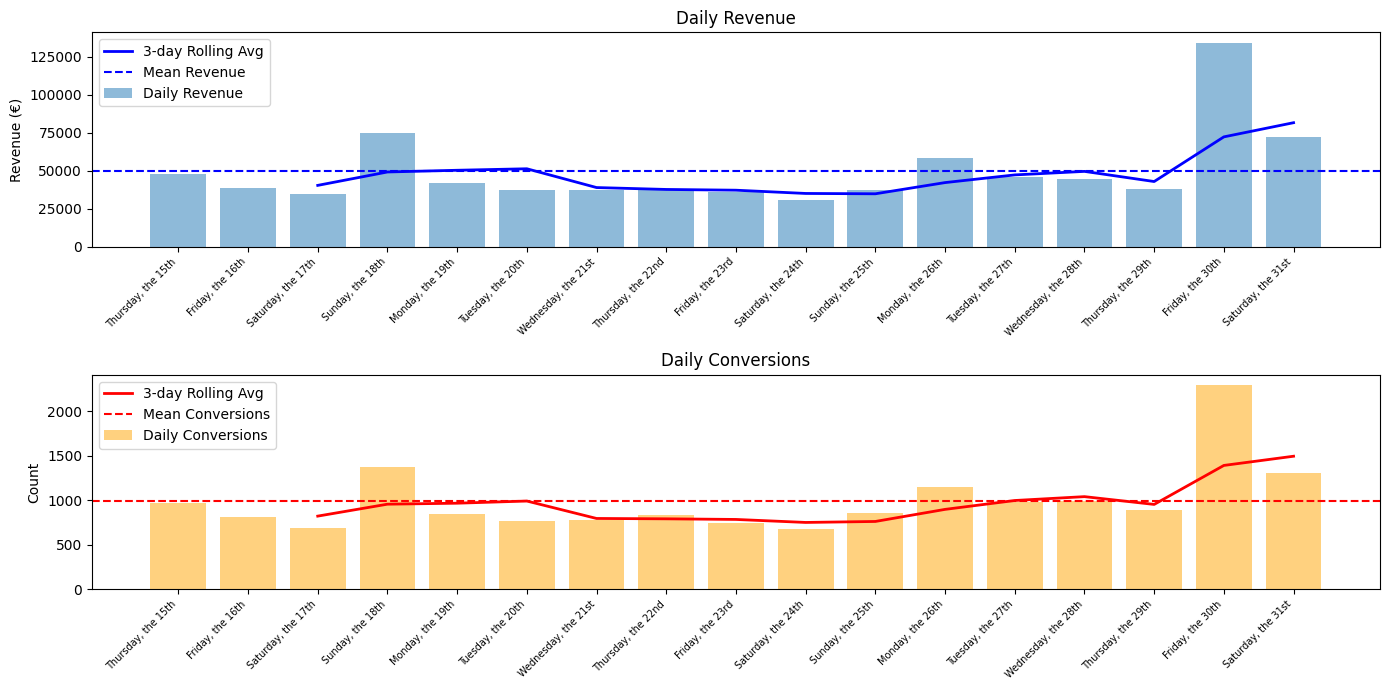

In [27]:
import matplotlib.pyplot as plt

df = pd.read_sql("""
    SELECT
        conv_date as day,
        SUM(revenue) as total_revenue,
        COUNT(*) as num_conversions
    FROM conversions
    GROUP BY day
    ORDER BY day
""", db)

df['day'] = pd.to_datetime(df['day'])

def ordinal(n):
    suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10 if n % 100 not in [11, 12, 13] else 0, 'th')
    return f"{n}{suffix}"

df['day_label'] = df['day'].apply(lambda d: f"{d.strftime('%A')}, the {ordinal(d.day)}")
df['rolling_revenue'] = df['total_revenue'].rolling(3).mean()
df['rolling_conversions'] = df['num_conversions'].rolling(3).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

# Revenue
ax1.bar(df['day'], df['total_revenue'], alpha=0.5, label='Daily Revenue')
ax1.plot(df['day'], df['rolling_revenue'], color='blue', linewidth=2, label='3-day Rolling Avg')
ax1.axhline(df['total_revenue'].mean(), color='blue', linewidth=1.5, linestyle='--', label='Mean Revenue')
ax1.set_title('Daily Revenue')
ax1.set_ylabel('Revenue (€)')
ax1.legend()
ax1.set_xticks(df['day'])
ax1.set_xticklabels(df['day_label'], rotation=45, ha='right', fontsize=7)

# Conversions
ax2.bar(df['day'], df['num_conversions'], color='orange', alpha=0.5, label='Daily Conversions')
ax2.plot(df['day'], df['rolling_conversions'], color='red', linewidth=2, label='3-day Rolling Avg')
ax2.axhline(df['num_conversions'].mean(), color='red', linewidth=1.5, linestyle='--', label='Mean Conversions')
ax2.set_title('Daily Conversions')
ax2.set_ylabel('Count')
ax2.legend()
ax2.set_xticks(df['day'])
ax2.set_xticklabels(df['day_label'], rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()

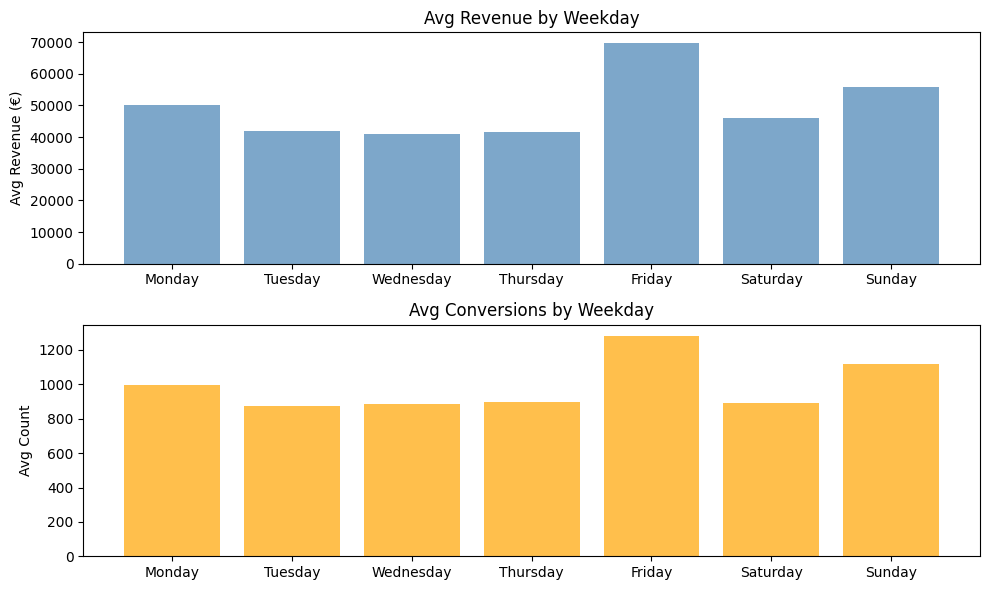

In [13]:
weekday_avg = df.groupby('weekday').agg(
    avg_revenue=('total_revenue', 'mean'),
    avg_conversions=('num_conversions', 'mean')
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.bar(weekday_avg.index, weekday_avg['avg_revenue'], color='steelblue', alpha=0.7)
ax1.set_title('Avg Revenue by Weekday')
ax1.set_ylabel('Avg Revenue (€)')

ax2.bar(weekday_avg.index, weekday_avg['avg_conversions'], color='orange', alpha=0.7)
ax2.set_title('Avg Conversions by Weekday')
ax2.set_ylabel('Avg Count')

plt.tight_layout()
plt.show()

**Answer 2: The conversions appear to be stable over time, however towards the end of the month. When grouping by day, I did not see a clear outlier. Friday and Sunday are over the rest, but it seems like the trend towards the end of the month is stronger!**

**Question 3:Double check conversions ('conversions' table) with backend ('conversions_backend' table), any issues?**


Only in conversions (frontend): 0
Only in conversions_backend: 345

Conversions with field-level discrepancies: 188


,conv_id,user_front,user_back,date_front,date_back,market_front,market_back,rev_front,rev_back,rev_diff
0,conv_id_11478,user_id_758246,user_id_758246,2021-07-15,2021-07-15,DE,DE,0.0,24.28,-24.28
1,conv_id_87,user_id_376090,user_id_376090,2021-07-15,2021-07-15,FR,FR,0.0,69.96,-69.96
2,conv_id_15098,user_id_47785,user_id_47785,2021-07-15,2021-07-15,NL,NL,0.0,8.26,-8.26
3,conv_id_16021,user_id_173269,user_id_173269,2021-07-15,2021-07-15,DE,DE,0.0,49.08,-49.08
4,conv_id_12754,user_id_561494,user_id_561494,2021-07-15,2021-07-15,DE,DE,0.0,75.30,-75.30
5,conv_id_1544,user_id_456436,user_id_456436,2021-07-15,2021-07-15,FR,FR,0.0,82.49,-82.49
6,conv_id_871,user_id_1149074,user_id_1149074,2021-07-15,2021-07-15,DE,DE,0.0,55.13,-55.13
7,conv_id_110,user_id_901822,user_id_901822,2021-07-15,2021-07-15,BE,BE,0.0,33.47,-33.47
8,conv_id_5060,user_id_81831,user_id_81831,2021-07-15,2021-07-15,DE,DE,0.0,56.48,-56.48
9,conv_id_1056,user_id_484328,user_id_484328,2021-07-15,2021-07-15,GB,GB,0.0,15.79,-15.79



Total revenue front:   849,102.67 €
Total revenue backend: 877,250.86 €
Net difference:        -28,148.19 €
Total conversions front:   16954
Total conversions backend: 17283


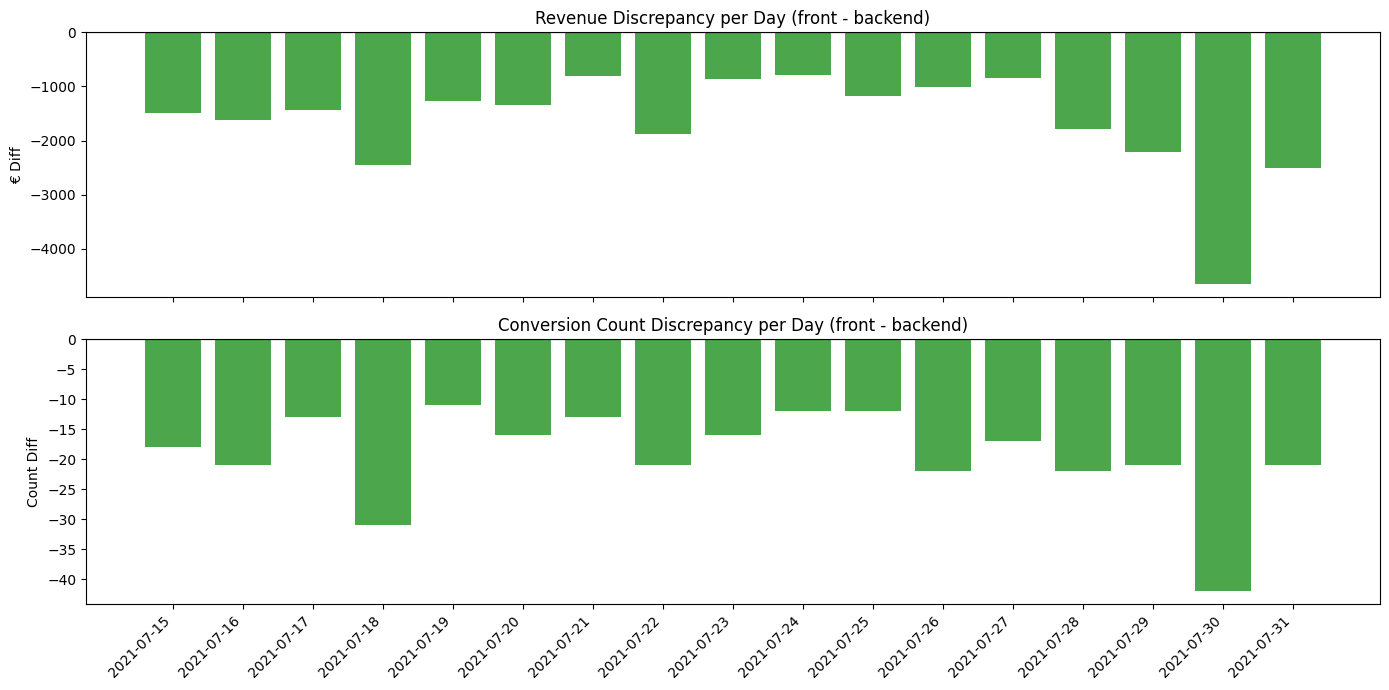

In [14]:
# 1. IDs nur in einer Tabelle
only_in_front = pd.read_sql("""
    SELECT conv_id FROM conversions
    WHERE conv_id NOT IN (SELECT conv_id FROM conversions_backend)
""", db)

only_in_back = pd.read_sql("""
    SELECT conv_id FROM conversions_backend
    WHERE conv_id NOT IN (SELECT conv_id FROM conversions)
""", db)

print(f"Only in conversions (frontend): {len(only_in_front)}")
print(f"Only in conversions_backend: {len(only_in_back)}")

# 2. Abweichungen auf conv_id-Level
df_diff = pd.read_sql("""
    SELECT 
        c.conv_id,
        c.user_id as user_front, cb.user_id as user_back,
        c.conv_date as date_front, cb.conv_date as date_back,
        c.market as market_front, cb.market as market_back,
        c.revenue as rev_front, cb.revenue as rev_back,
        c.revenue - cb.revenue as rev_diff
    FROM conversions c
    JOIN conversions_backend cb ON c.conv_id = cb.conv_id
    WHERE c.revenue != cb.revenue
       OR c.conv_date != cb.conv_date
       OR c.market != cb.market
       OR c.user_id != cb.user_id
""", db)

print(f"\nConversions with field-level discrepancies: {len(df_diff)}")
display(df_diff.head(20))

# 3. Tagesaggregat + Chart
df_front = pd.read_sql("""
    SELECT conv_date as day, SUM(revenue) as total_revenue, COUNT(*) as num_conversions
    FROM conversions GROUP BY day ORDER BY day
""", db)

df_back = pd.read_sql("""
    SELECT conv_date as day, SUM(revenue) as total_revenue, COUNT(*) as num_conversions
    FROM conversions_backend GROUP BY day ORDER BY day
""", db)

df = df_front.merge(df_back, on='day', suffixes=('_front', '_back'), how='outer').fillna(0)
df['revenue_diff'] = df['total_revenue_front'] - df['total_revenue_back']
df['conversions_diff'] = df['num_conversions_front'] - df['num_conversions_back']

# 4. Summary
print(f"\nTotal revenue front:   {df['total_revenue_front'].sum():,.2f} €")
print(f"Total revenue backend: {df['total_revenue_back'].sum():,.2f} €")
print(f"Net difference:        {df['revenue_diff'].sum():,.2f} €")
print(f"Total conversions front:   {int(df['num_conversions_front'].sum())}")
print(f"Total conversions backend: {int(df['num_conversions_back'].sum())}")

# 5. Chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.bar(df['day'], df['revenue_diff'], color=df['revenue_diff'].apply(lambda x: 'red' if x > 0 else 'green'), alpha=0.7)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title('Revenue Discrepancy per Day (front - backend)')
ax1.set_ylabel('€ Diff')

ax2.bar(df['day'], df['conversions_diff'], color=df['conversions_diff'].apply(lambda x: 'red' if x > 0 else 'green'), alpha=0.7)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Conversion Count Discrepancy per Day (front - backend)')
ax2.set_ylabel('Count Diff')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Answer 3**: Three issues were identified when cross-referencing the conversions table against conversions_backend:

Missing conversions: 345 conv_ids exist in the backend but are absent from the frontend table — these conversions were never tracked on the frontend side.
Field-level discrepancies: 188 shared conv_ids have at least one mismatching field (revenue, date, or market), indicating data corruption or transformation errors in the frontend pipeline.
Revenue gap: Total frontend revenue is €849,102 vs. €877,250 in the backend — a net underreporting of €28,148 (~3.2%). This is significant for any revenue reporting or attribution calculations downstream.
The backend should be treated as the source of truth; the frontend pipeline requires investigation.**

**Question 4: Are attribution results consistent? Do you find any conversions where the 'ihc' values don't make sense?**


In [31]:
df_ihc = pd.read_sql("""
    SELECT conv_id, SUM(ihc) as ihc_sum, COUNT(*) as num_sessions
    FROM attribution_customer_journey
    GROUP BY conv_id
""", db)

# Abweichungen von 1 (mit kleinem float-tolerance)
df_nonissues = df_ihc[abs(df_ihc['ihc_sum'] - 1.0) < 0.01]
df_issues = df_ihc[abs(df_ihc['ihc_sum'] - 1.0) > 0.01]

print(f"Conversions with IHC sum != 1: {len(df_issues)}")
print(len(df_nonissues))
print(len(df_issues))
print(f"Percentage of issues: {len(df_issues) / len(df_ihc) * 100:.2f}%")

Conversions with IHC sum != 1: 155
6845
155
Percentage of issues: 2.21%


In [32]:
only_in_journey = pd.read_sql("""
    SELECT DISTINCT conv_id FROM attribution_customer_journey
    WHERE conv_id NOT IN (SELECT conv_id FROM conversions)
""", db)

print(f"Conv_ids in journey but not in conversions: {len(only_in_journey)}")

# Umgekehrt: Conversions ohne Journey
no_journey = pd.read_sql("""
    SELECT conv_id FROM conversions
    WHERE conv_id NOT IN (SELECT conv_id FROM attribution_customer_journey)
""", db)

print(f"Conversions without any journey: {len(no_journey)}")

Conv_ids in journey but not in conversions: 138
Conversions without any journey: 10087


In [33]:
orphan_sessions = pd.read_sql("""
    SELECT DISTINCT session_id FROM attribution_customer_journey
    WHERE session_id NOT IN (SELECT session_id FROM session_sources)
""", db)

print(f"Session_ids in journey but not in session_sources: {len(orphan_sessions)}")

Session_ids in journey but not in session_sources: 0


**Bonus: Are there any issues with challenging?**

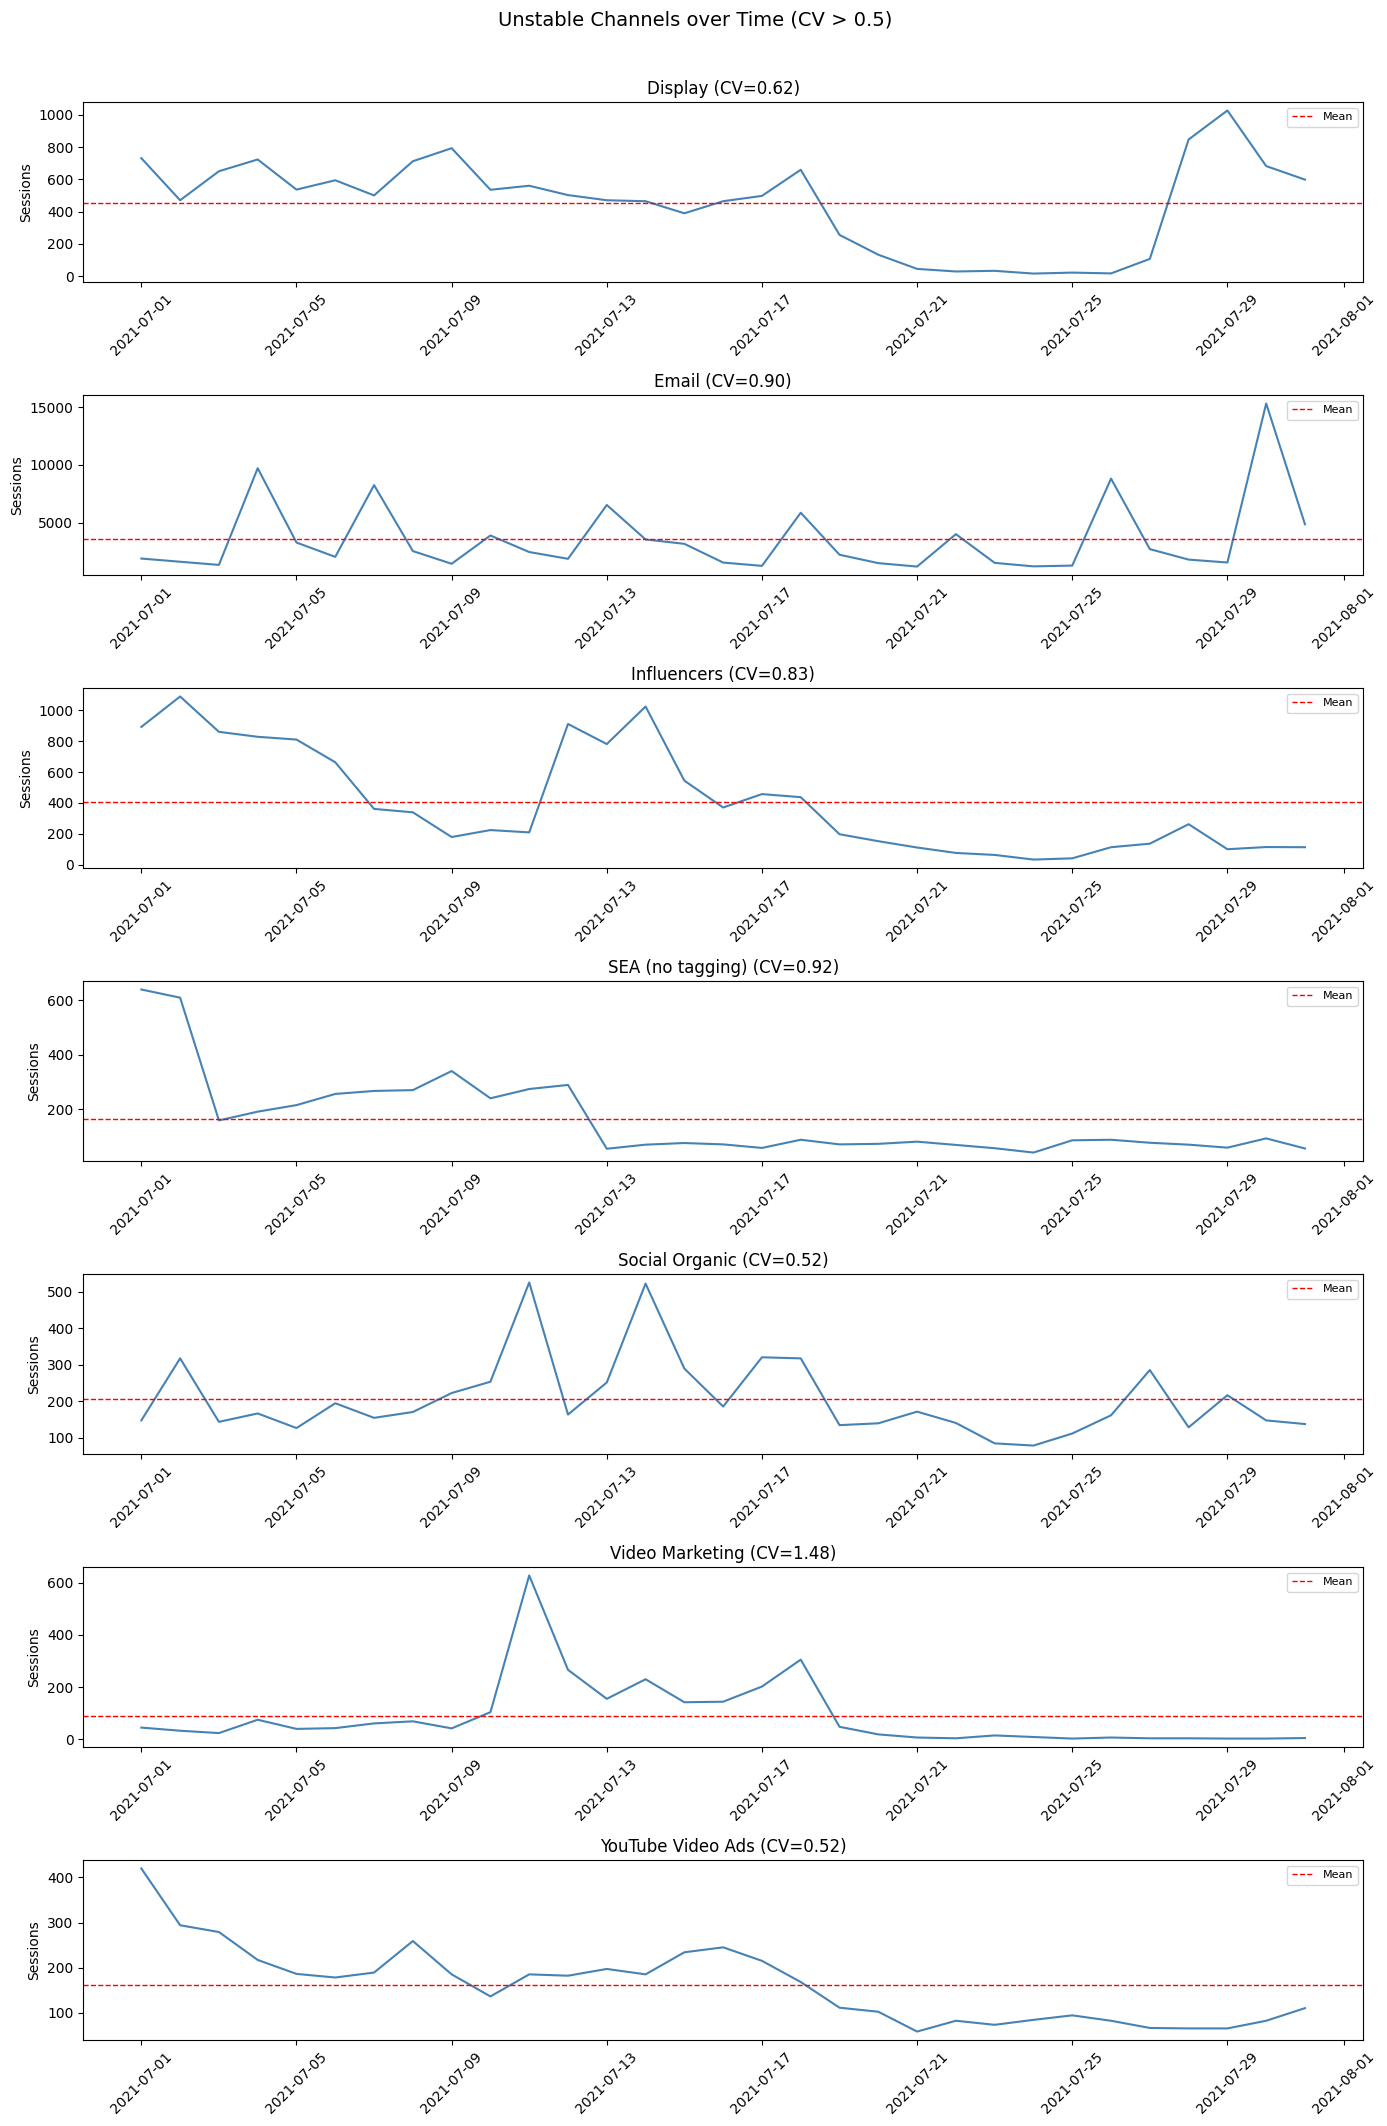

                                std          mean        cv
channel_name                                               
Video Marketing          130.474362     88.322581  1.477248
SEA (no tagging)         151.803545    165.129032  0.919303
Email                   3212.517182   3554.225806  0.903858
Influencers              335.939354    402.870968  0.833863
Display                  282.012316    454.290323  0.620776
Social Organic           108.128687    206.290323  0.524158
YouTube Video Ads         84.864763    162.193548  0.523231
Social Paid              509.364894   1072.064516  0.475125
Google Remarketing        38.366092    109.903226  0.349090
Social Remarketing       403.458250   1409.677419  0.286206
Social - Paid           1580.828083   5718.193548  0.276456
Social - Organic         187.199376    757.161290  0.247238
SEA - Non-Brand          319.014403   1323.548387  0.241030
Affiliate                163.280615    685.322581  0.238254
Shopping - Non Brand     385.773495   16

In [35]:
df = pd.read_sql("""
    SELECT
        event_date,
        channel_name,
        COUNT(session_id) as num_sessions
    FROM session_sources
    GROUP BY event_date, channel_name
    ORDER BY event_date
""", db)

df['event_date'] = pd.to_datetime(df['event_date'])

# Calculate CV per channel
cv = df.groupby('channel_name')['num_sessions'].agg(['std', 'mean'])
cv['cv'] = cv['std'] / cv['mean']
unstable_channels = cv[cv['cv'] > 0.5].index

df_unstable = df[df['channel_name'].isin(unstable_channels)]

# One subplot per unstable channel
fig, axes = plt.subplots(len(unstable_channels), 1, figsize=(14, 3 * len(unstable_channels)))

for ax, channel in zip(axes, unstable_channels):
    group = df_unstable[df_unstable['channel_name'] == channel]
    ax.plot(group['event_date'], group['num_sessions'], color='steelblue')
    ax.axhline(group['num_sessions'].mean(), color='red', linestyle='--', linewidth=1, label='Mean')
    ax.set_title(f"{channel} (CV={cv.loc[channel,'cv']:.2f})")
    ax.set_ylabel('Sessions')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Unstable Channels over Time (CV > 0.5)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(cv.sort_values('cv', ascending=False))

**Three channels show high coefficient of variation (CV > 0.5), indicating unstable session volumes:**

Video Marketing (CV: 1.48) — extremely volatile, likely due to campaign bursts with no consistent activity
SEA (no tagging) (CV: 0.92) — high variance and the "no tagging" label is itself a data quality issue; these sessions lack proper campaign attribution
Email (CV: 0.90) — expected to be bursty by nature (newsletter sends), so less alarming
The SEA (no tagging) channel warrants the most attention: sessions arriving via paid search without a campaign tag cannot be linked to AdWords costs, creating a blind spot in cost-per-conversion reporting.

##

##